In [1]:
import metric
def get_score_img(img, aes=True, ocr=True):
    image_processor = metric.ImageProcessor(image=img, seed=42).apply()
    image = image_processor.image.copy()
    
    aesthetic_score = metric.aesthetic_evaluator.score(image) if aes else 1.0

    if ocr:
        image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
        ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    else:
        ocr_score = 1.0

    return aesthetic_score, ocr_score


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

decoded text =  100
decoded text =  100
Does <image> portray "SVG illustration of a red circle" without any lettering? Answer yes or no.
decoded text =  100
decoded text =  100


In [ ]:
import torch
from math import ceil
from diffusers import StableDiffusionXLPipeline, DDIMScheduler, AutoencoderKL
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display

seed = 33
generator = torch.Generator(device="cuda").manual_seed(seed)


# your scoring fn
def get_score_img(img, aes=True, ocr=True):
    image_processor = metric.ImageProcessor(image=img, seed=42).apply()
    image = image_processor.image.copy()
    aesthetic_score = metric.aesthetic_evaluator.score(image) if aes else 1.0
    if ocr:
        image_processor.reset().apply_random_crop_resize().apply_jpeg_compression(quality=90)
        ocr_score = metric.vqa_evaluator.ocr(image_processor.image)
    else:
        ocr_score = 1.0
    return aesthetic_score, ocr_score

# 1) Load SDXL in FP16
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

# 2) Swap in your FP16 VAE
pipe.vae = AutoencoderKL.from_pretrained(
    "sdxl-vae-fp16-fix",
    torch_dtype=torch.float16,
    use_safetensors=True
).to("cuda")

# 3) Use DDIM
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

# decode helper
def preview_fp16_latent(pipe, latents):
    lat = (latents / pipe.vae.config.scaling_factor).clamp(-5.0, 5.0)
    with torch.no_grad():
        dec = pipe.vae.decode(lat).sample
    return pipe.image_processor.postprocess(dec, output_type="pil")[0]

def on_step(pipe, step_idx, timestep, cb_kwargs):
    # 1) decode full-res and thumb
    lat = cb_kwargs["latents"]
    img_full = preview_fp16_latent(pipe, lat)
    thumb_img = img_full.resize((thumb, thumb), Image.LANCZOS)
    
    # 2) score it
    aes, ocr = get_score_img(thumb_img, aes=True, ocr=True)
    score_line = f"aes={aes:.2f}, ocr={ocr:.2f}"
    
    # 3) measure text heights
    step_label = f"Step {step_idx}"
    try:
        w1, h1 = font.getsize(step_label)
        w2, h2 = font.getsize(score_line)
    except AttributeError:
        draw_tmp = ImageDraw.Draw(thumb_img)
        b1 = draw_tmp.textbbox((0,0), step_label, font=font)
        b2 = draw_tmp.textbbox((0,0), score_line, font=font)
        w1, h1 = b1[2]-b1[0], b1[3]-b1[1]
        w2, h2 = b2[2]-b2[0], b2[3]-b2[1]
    
    # 4) build cell: two text rows + thumbnail
    cell_h = h1 + h2 + 4 + thumb  # 2px padding above and between
    cell = Image.new("RGB", (thumb, cell_h), color=(255,255,255))
    d = ImageDraw.Draw(cell)
    # draw step label
    x1 = (thumb - w1)//2
    d.text((x1, 0), step_label, font=font, fill="black")
    # draw score line beneath
    x2 = (thumb - w2)//2
    d.text((x2, h1 + 2), score_line, font=font, fill="black")
    # paste thumb below texts
    cell.paste(thumb_img, (0, h1 + h2 + 4))
    
    step_cells.append(cell)
    return {"latents": lat}



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

decoded text =  100
decoded text =  100
decoded text =  100
decoded text =  10
decoded text =  www.
decoded text =  1
decoded text =  1
decoded text =  1


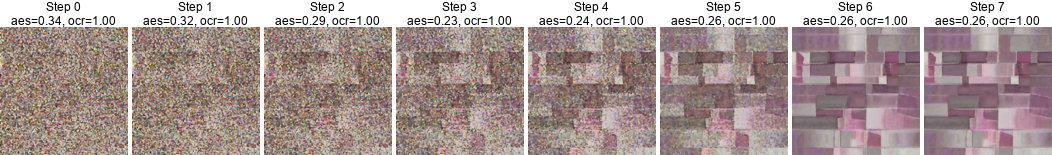

In [5]:
# collect cells
step_cells = []
thumb = 128
gap = 4

# font
try:
    font = ImageFont.truetype("arial.ttf", 12)
except OSError:
    font = ImageFont.load_default()

# run with 8 steps → 8 cells
_ = pipe(
    "megenta trapezoids layered on a traslucent silver sheet",
    num_inference_steps=8,
    guidance_scale=20,
    generator=generator,
    output_type="latent",
    callback_on_step_end=on_step,
    callback_on_step_end_tensor_inputs=["latents"]
)

# tile 8 per row
n = len(step_cells)
cols = 8
rows = ceil(n / cols)
cw, ch = step_cells[0].size
W = cols*cw + (cols-1)*gap
H = rows*ch + (rows-1)*gap
canvas = Image.new("RGB", (W, H), color=(255,255,255))

for i, cell in enumerate(step_cells):
    r, c = divmod(i, cols)
    x, y = c*(cw+gap), r*(ch+gap)
    canvas.paste(cell, (x,y))

# crop last row if not full
if n % cols:
    last = n%cols
    crop_w = last*cw + (last-1)*gap
    canvas = canvas.crop((0,0,crop_w,H))

display(canvas)
